# UMAP delle tile di una WSI colorata con attenzione TITAN

Questo notebook visualizza gli embedding CONCH finali di una singola WSI. Ogni punto UMAP è colorato usando la media, su layer e teste, della mappa TITAN `global_to_tiles_mass_share`. Il valore è attenzione nativa catturata post-softmax, non una probabilità diagnostica o causale.

In [28]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError(
        'Install UMAP in the active environment first: pip install umap-learn==0.5.7'
    ) from exc


In [29]:
# Configure one slide. Change only this identifier to inspect another WSI.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SLIDE_ID = 'TCGA-02-0025-01Z-00-DX2.aa8923a0-2930-47f4-bbff-ceb080fafc9e'
FEATURE_DIR = PROJECT_ROOT / 'data/wsi/tcga1000_antibench/processed/trident/20x_512px_stride512/tile_features/conch_v15_final_d768'
ATTENTION_DIR = PROJECT_ROOT / 'artifacts/wsi_attention/titan_real_tile_maps_20260803'
FEATURE_PATH = FEATURE_DIR / f'{SLIDE_ID}.h5'
ATTENTION_PATH = ATTENTION_DIR / f'{SLIDE_ID}.h5'

# Set a smaller value for a faster exploratory plot. None uses every tile.
MAX_TILES = None
RANDOM_SEED = 17
assert FEATURE_PATH.exists(), FEATURE_PATH
assert ATTENTION_PATH.exists(), ATTENTION_PATH


In [30]:
with h5py.File(FEATURE_PATH, 'r') as feature_file:
    embeddings = np.asarray(feature_file['features'] if 'features' in feature_file else feature_file['embeddings']['final'], dtype=np.float32)
    embeddings = embeddings[:, 0, :] if embeddings.ndim == 3 and embeddings.shape[1] == 1 else embeddings

with h5py.File(ATTENTION_PATH, 'r') as attention_file:
    coords = np.asarray(attention_file['coords'], dtype=np.int32)
    raw_attention = np.asarray(attention_file['attention']['global_to_tiles_mass_share'], dtype=np.float32)
    attention_source = attention_file.attrs['attention_source']

# [layers, heads, tiles] -> [tiles]. Keep the probability mass separately,
# then min–max normalize only for a 0–1 visual color scale.
attention_probability = raw_attention.mean(axis=(0, 1))
attention_probability /= attention_probability.sum()
attention = (attention_probability - attention_probability.min()) / np.clip(
    attention_probability.max() - attention_probability.min(), 1e-12, None
)
assert len(embeddings) == len(coords) == len(attention)
print(f'{SLIDE_ID}: {len(attention):,} tiles, embedding dimension {embeddings.shape[1]}')
print(f'Attention source: {attention_source}')
print('Visualization scale: min–max normalized attention in [0, 1]')


TCGA-02-0025-01Z-00-DX2.aa8923a0-2930-47f4-bbff-ceb080fafc9e: 5,755 tiles, embedding dimension 768
Attention source: real_post_softmax_runtime_capture
Visualization scale: min–max normalized attention in [0, 1]


In [31]:
rng = np.random.default_rng(RANDOM_SEED)
indices = np.arange(len(attention))
if MAX_TILES is not None and len(indices) > MAX_TILES:
    indices = np.sort(rng.choice(indices, size=MAX_TILES, replace=False))

# Cosine-compatible normalization, then PCA before Euclidean UMAP.
selected_embeddings = embeddings[indices]
selected_embeddings /= np.clip(np.linalg.norm(selected_embeddings, axis=1, keepdims=True), 1e-8, None)
n_pca_components = min(50, selected_embeddings.shape[0] - 1, selected_embeddings.shape[1])
if n_pca_components < 2:
    raise ValueError('At least three tile embeddings are required for PCA followed by UMAP.')
pca_embeddings = PCA(n_components=n_pca_components, random_state=RANDOM_SEED).fit_transform(selected_embeddings)
umap_xy = umap.UMAP(n_neighbors=30, min_dist=0.15, metric='euclidean', random_state=RANDOM_SEED).fit_transform(pca_embeddings)


/data2/home/vcivale/miniconda3/envs/tahoe-x1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


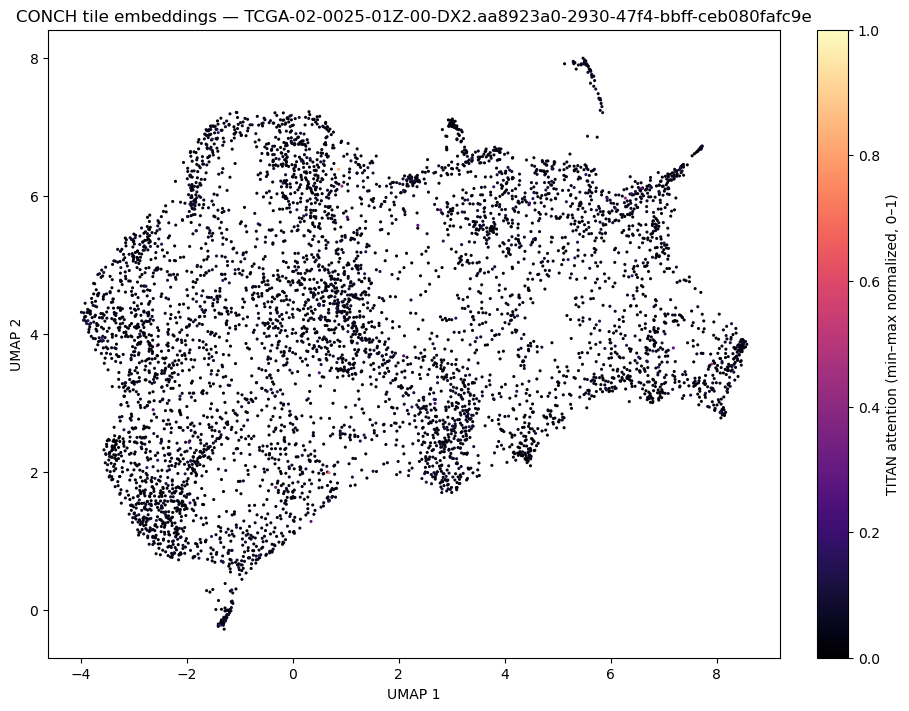

In [32]:
color_values = attention[indices]
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
points = ax.scatter(umap_xy[:, 0], umap_xy[:, 1], c=color_values, s=5, cmap='magma', linewidths=0, rasterized=True)
fig.colorbar(points, ax=ax, label='TITAN attention (min–max normalized, 0–1)')
ax.set(title=f'CONCH tile embeddings — {SLIDE_ID}', xlabel='UMAP 1', ylabel='UMAP 2')
plt.show()


## Heatmap spaziale sulla WSI

La sovrapposizione usa le coordinate level-0 salvate con le feature. I punti rappresentano le tile e il colore usa direttamente la massa di attenzione.

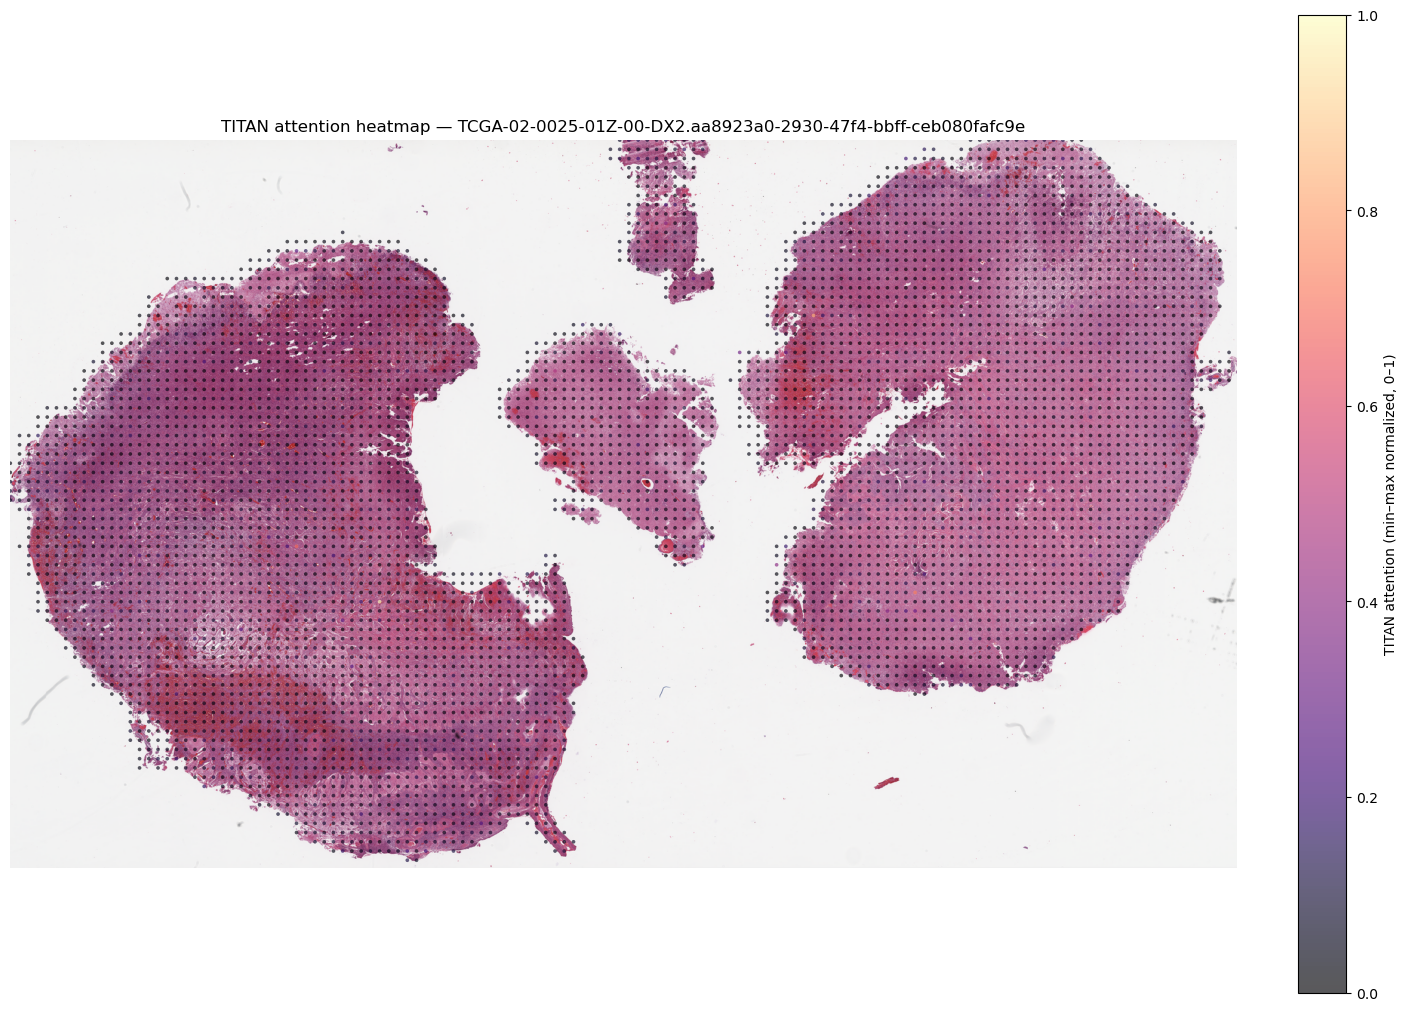

In [33]:
import pandas as pd
import openslide

DATASET_ROOT = PROJECT_ROOT / 'data/wsi/tcga1000_antibench'
slides = pd.read_csv(DATASET_ROOT / 'registry/slides.csv')
wsi_relative_path = slides.loc[slides['slide_id'].eq(SLIDE_ID), 'wsi_path'].iloc[0]
wsi_path = DATASET_ROOT / wsi_relative_path
assert wsi_path.exists(), wsi_path

slide = openslide.OpenSlide(str(wsi_path))
level0_width, level0_height = slide.dimensions
thumbnail = np.asarray(slide.get_thumbnail((2000, 2000)).convert('RGB'))
slide.close()
scale_x = thumbnail.shape[1] / level0_width
scale_y = thumbnail.shape[0] / level0_height

MIN_ATTENTION_PERCENTILE = 0  # Increase to e.g. 90 to display only the top 10%.
mask = attention >= np.percentile(attention, MIN_ATTENTION_PERCENTILE)
fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
ax.imshow(thumbnail)
overlay = ax.scatter(coords[mask, 0] * scale_x, coords[mask, 1] * scale_y, c=attention[mask], cmap='magma', s=7, alpha=0.65, linewidths=0)
fig.colorbar(overlay, ax=ax, label='TITAN attention (min–max normalized, 0–1)')
ax.set_title(f'TITAN attention heatmap — {SLIDE_ID}')
ax.axis('off')
plt.show()


In [34]:
# Coordinates of the most attended tiles can be used to overlay the result on the WSI.
n_top = max(1, int(np.ceil(0.01 * len(attention))))
top_idx = np.argsort(attention)[-n_top:][::-1]
top_tiles = {'tile_index': top_idx, 'x': coords[top_idx, 0], 'y': coords[top_idx, 1], 'attention': attention[top_idx]}
import pandas as pd
pd.DataFrame(top_tiles).head(20)


,tile_index,x,y,attention
0,4243,20480,25600,1.000000
1,1091,44544,9728,0.838876
2,4183,50176,25088,0.737894
3,3677,15872,22528,0.689785
4,1675,30208,12800,0.472183
5,318,36352,4608,0.400479
6,3879,42496,23552,0.390952
7,1033,58880,9216,0.384448
8,4374,48640,26112,0.369386
9,4311,5632,26112,0.360045
